# Assignment 4 — Data Wrangling on Heart Disease Dataset

## Topic Explanation

**Data Wrangling** (also called *data cleaning* or *data munging*) is the process of taking raw, messy, real-world data and transforming it into a clean, structured form ready for analysis. It typically takes **60–80% of the total time** in a data-science project. The famous saying: **"garbage in, garbage out"** — even the best ML algorithm fails on dirty data.

### About the Dataset
The Heart Disease dataset contains medical records used to predict heart disease. It has **14 columns**:

| Column | Meaning | Type |
|--------|---------|------|
| `age` | Age in years | Numeric |
| `sex` | 0 = female, 1 = male | Binary |
| `cp` | Chest pain type (0–3) | Categorical |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (0/1) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical |
| `thalach` | Maximum heart rate achieved | Numeric |
| `exang` | Exercise-induced angina (0/1) | Binary |
| `oldpeak` | ST depression induced by exercise | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical |
| `ca` | Number of major vessels (0–4) | Numeric |
| `thal` | Thalassemia type (0–3) | Categorical |
| `target` | 1 = has heart disease, 0 = healthy | Binary |

### Three Operations We'll Perform

#### 1. Missing Values & Inconsistencies
- **Missing values** are NaN cells — we fill them with the column **median** (robust to outliers)
- **Inconsistencies** are values that are present but invalid — like a negative age. We replace them with NaN, then impute.

#### 2. Outliers
We detect outliers using the **IQR rule**:
- IQR = Q3 − Q1
- Outlier if value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR

We treat them via **winsorization (capping)** — replacing extreme values with the boundary instead of removing rows.

#### 3. Data Transformation
We apply a **log transformation** to a right-skewed variable (cholesterol) to reduce its skewness and make the distribution more normal.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations; provides np.nan and mathematical functions like log1p
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads a CSV into a pandas DataFrame
df = pd.read_csv('heart_disease.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,36.0,0,0,179.0,385.0,0,0,91,1,4.5,0,3,3,0
1,38.0,0,3,167.0,164.0,1,2,201,0,5.7,1,2,3,1
2,74.0,1,1,154.0,179.0,0,0,152,0,5.7,2,0,1,1
3,33.0,1,3,151.0,286.0,0,1,158,1,4.6,1,2,3,0
4,47.0,1,1,124.0,414.0,0,1,181,0,1.2,1,1,3,0


In [3]:
# info() — column names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       299 non-null    float64
 1   sex       300 non-null    int64  
 2   cp        300 non-null    int64  
 3   trestbps  299 non-null    float64
 4   chol      299 non-null    float64
 5   fbs       300 non-null    int64  
 6   restecg   300 non-null    int64  
 7   thalach   300 non-null    int64  
 8   exang     300 non-null    int64  
 9   oldpeak   300 non-null    float64
 10  slope     300 non-null    int64  
 11  ca        300 non-null    int64  
 12  thal      300 non-null    int64  
 13  target    300 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 32.9 KB


In [4]:
# describe() — summary statistics for numeric columns
# Watch the min/max values — anything biologically impossible is a red flag
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,299.000000,300.000000,300.000000,299.000000,299.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,52.227425,0.503333,1.410000,147.919732,334.585284,0.470000,1.053333,136.473333,0.503333,3.209333,0.970000,1.976667,1.640000,0.506667
std,14.531675,0.500824,1.131149,29.430847,132.069213,0.499933,0.832345,37.488673,0.500824,1.839927,0.790263,1.473100,1.123063,0.500791
min,-5.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,0.000000,124.000000,219.500000,0.000000,0.000000,104.750000,0.000000,1.700000,0.000000,1.000000,1.000000,0.000000
50%,51.000000,1.000000,1.000000,149.000000,333.000000,0.000000,1.000000,136.000000,1.000000,3.200000,1.000000,2.000000,2.000000,1.000000
75%,65.000000,1.000000,2.000000,173.000000,446.500000,1.000000,2.000000,167.000000,1.000000,4.825000,2.000000,3.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,199.000000,999.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Operation 1 — Missing Values & Inconsistencies

We tackle this in two parts:
- **3.1 Missing values** — empty cells (NaN)
- **3.2 Inconsistencies** — values that exist but are invalid (e.g., negative age, cholesterol = 999)

### 3.1 Detect Missing Values

In [5]:
# isnull() returns True for every NaN; .sum() counts them per column
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
age         1
sex         0
cp          0
trestbps    1
chol        1
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing cells: 3


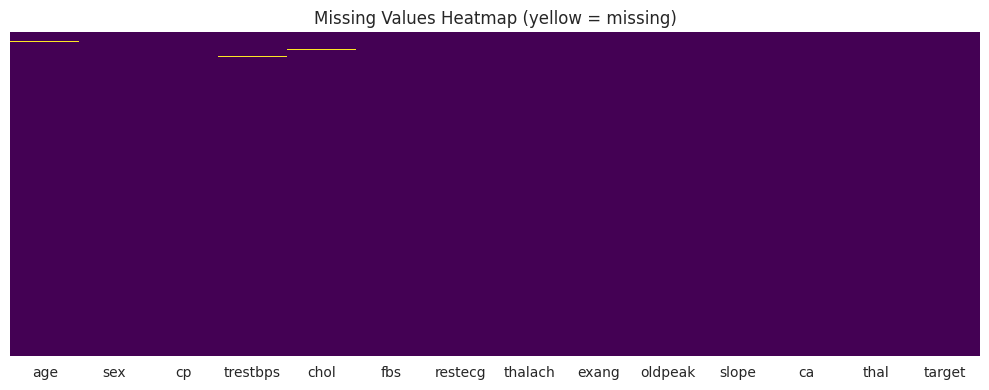

In [6]:
# Visualize missing values as a heatmap — yellow stripes mark NaN cells
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

### 3.2 Detect Invalid / Inconsistent Values

In [7]:
# Set up reasonable medical ranges for each column
print("Invalid age values (< 0 or > 120):")
print(df[(df['age'] < 0) | (df['age'] > 120)][['age']])

print("\nInvalid cholesterol values (< 0 or > 600):")
print(df[(df['chol'] < 0) | (df['chol'] > 600)][['chol']])

print("\nInvalid resting BP values (< 0 or > 250):")
print(df[(df['trestbps'] < 0) | (df['trestbps'] > 250)][['trestbps']])

Invalid age values (< 0 or > 120):
    age
30 -5.0

Invalid cholesterol values (< 0 or > 600):
     chol
44  999.0

Invalid resting BP values (< 0 or > 250):
Empty DataFrame
Columns: [trestbps]
Index: []


### 3.3 Replace Invalid Values with NaN, Then Impute

In [8]:
# Mark biologically impossible values as NaN so they get treated as missing data
df.loc[(df['age'] < 0) | (df['age'] > 120), 'age'] = np.nan
df.loc[(df['chol'] < 0) | (df['chol'] > 600), 'chol'] = np.nan
df.loc[(df['trestbps'] < 0) | (df['trestbps'] > 250), 'trestbps'] = np.nan

print("Missing values after flagging invalid entries:")
print(df.isnull().sum())

Missing values after flagging invalid entries:
age         2
sex         0
cp          0
trestbps    1
chol        2
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [9]:
# Fill all numeric NaNs with the column MEDIAN — robust to outliers
# Use assignment style to avoid pandas Copy-on-Write warnings
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:", df.isnull().sum().sum())
df.head()

Missing values after imputation: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,36.0,0,0,179.0,385.0,0,0,91,1,4.5,0,3,3,0
1,38.0,0,3,167.0,164.0,1,2,201,0,5.7,1,2,3,1
2,74.0,1,1,154.0,179.0,0,0,152,0,5.7,2,0,1,1
3,33.0,1,3,151.0,286.0,0,1,158,1,4.6,1,2,3,0
4,47.0,1,1,124.0,414.0,0,1,181,0,1.2,1,1,3,0


## Operation 2 — Outlier Detection & Treatment

An **outlier** is a value far from the rest of the data. We:
1. Visualize using **boxplots**
2. Detect numerically using the **IQR rule**
3. Treat by **capping (winsorization)** — replacing extreme values with IQR bounds

### 4.1 Visualize Outliers — Boxplots BEFORE Treatment

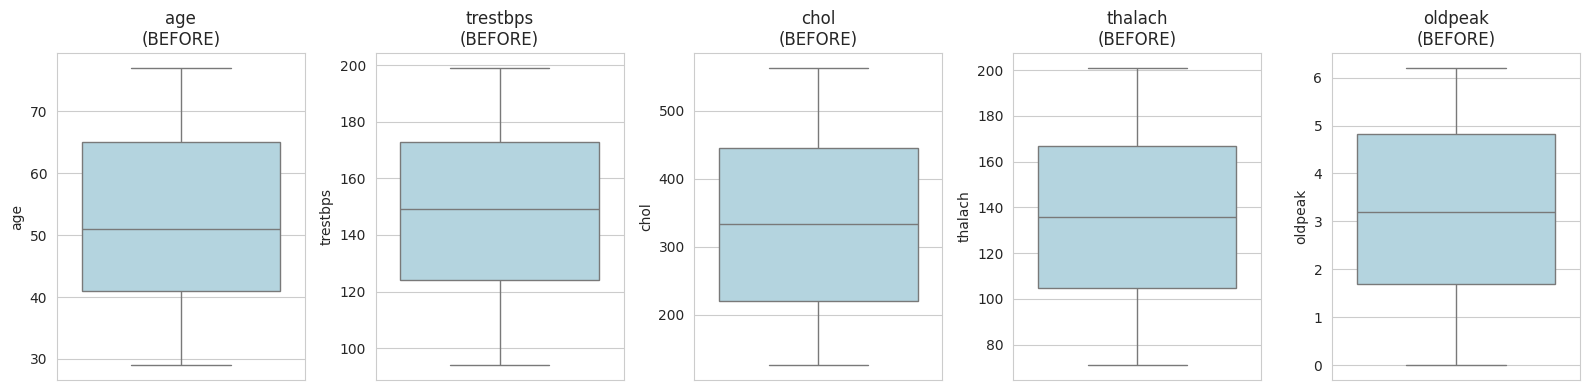

In [10]:
# Plot boxplots for the main numeric variables
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f'{col}\n(BEFORE)')

plt.tight_layout()
plt.show()

### 4.2 Detect Outliers Numerically (IQR Method)

In [11]:
def detect_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"  {name:<10} bounds=[{lower:.2f}, {upper:.2f}]  outliers = {len(outliers)}")
    return outliers

print("Outlier counts per numeric column:")
for col in numeric_cols:
    detect_outliers(df[col], col)

Outlier counts per numeric column:
  age        bounds=[5.00, 101.00]  outliers = 0
  trestbps   bounds=[50.50, 246.50]  outliers = 0
  chol       bounds=[-119.62, 785.38]  outliers = 0
  thalach    bounds=[11.38, 260.38]  outliers = 0
  oldpeak    bounds=[-2.99, 9.51]  outliers = 0


### 4.3 Cap Outliers (Winsorization)

In [12]:
def cap_outliers(series):
    """Replace values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] with the boundary values."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

# Apply capping to all numeric columns
for col in numeric_cols:
    df[col] = cap_outliers(df[col])

print("After capping, outlier counts:")
for col in numeric_cols:
    detect_outliers(df[col], col)

After capping, outlier counts:
  age        bounds=[5.00, 101.00]  outliers = 0
  trestbps   bounds=[50.50, 246.50]  outliers = 0
  chol       bounds=[-119.62, 785.38]  outliers = 0
  thalach    bounds=[11.38, 260.38]  outliers = 0
  oldpeak    bounds=[-2.99, 9.51]  outliers = 0


### 4.4 Boxplots AFTER Treatment

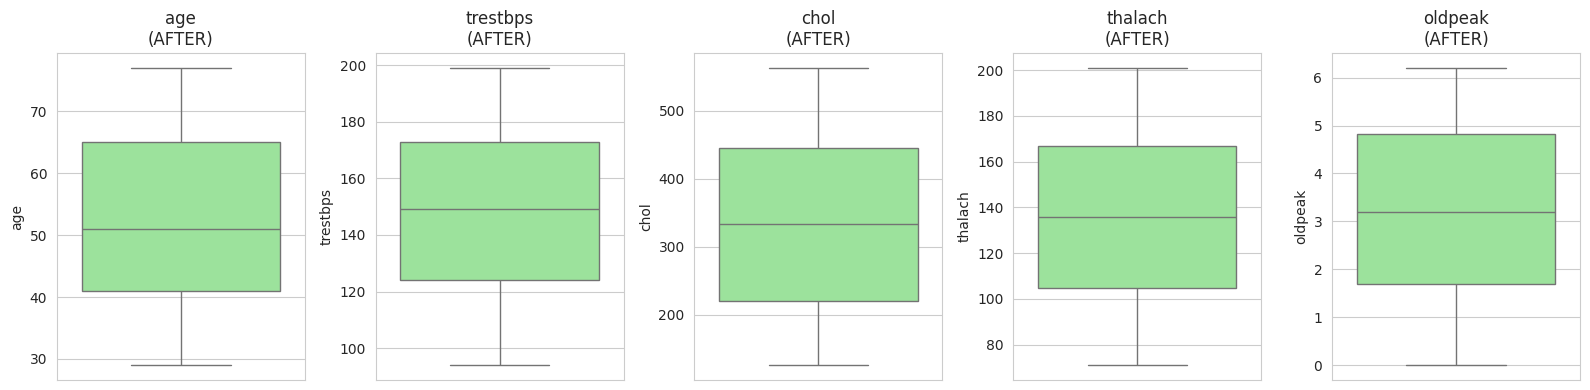

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col}\n(AFTER)')

plt.tight_layout()
plt.show()

## Operation 3 — Data Transformation

We apply a **log transformation** to **cholesterol (`chol`)** to reduce its skewness.

**Why?** Cholesterol values are typically right-skewed — most people have moderate values, but a few have very high values. Many statistical methods assume normally distributed data, so log-transforming makes the distribution closer to normal.

**How?** `np.log1p(x) = log(1 + x)` — handles zero values safely (since `log(0)` is undefined).

### 5.1 Check Skewness Before Transformation

In [14]:
# .skew() returns a number describing distribution asymmetry:
#   skew == 0  -> symmetric (normal)
#   skew  > 0  -> right-skewed (tail on right)
#   skew  < 0  -> left-skewed
print("Skewness of numeric variables:")
for col in numeric_cols:
    print(f"  {col:<10}: {df[col].skew():.4f}")

Skewness of numeric variables:
  age       : 0.1699
  trestbps  : -0.0942
  chol      : 0.0758
  thalach   : 0.0060
  oldpeak   : -0.0763


### 5.2 Original Cholesterol Distribution

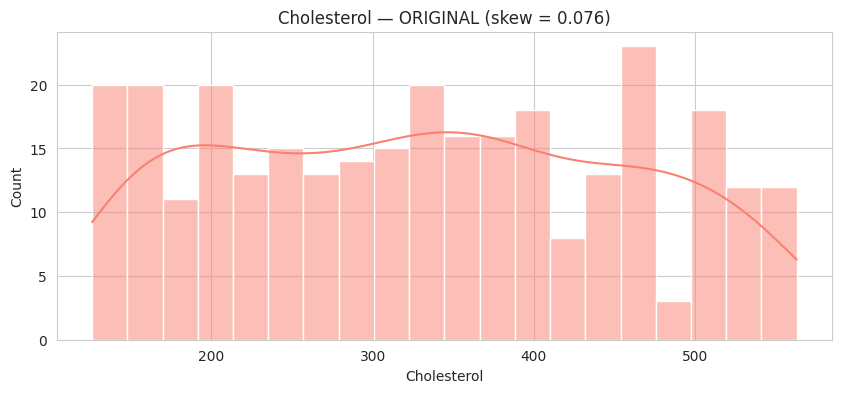

In [15]:
plt.figure(figsize=(10, 4))
sns.histplot(df['chol'], kde=True, color='salmon', bins=20)
plt.title(f"Cholesterol — ORIGINAL (skew = {df['chol'].skew():.3f})")
plt.xlabel('Cholesterol')
plt.show()

### 5.3 Apply Log Transformation

In [16]:
# log1p(x) = log(1 + x); safe for zero values
df['chol_log'] = np.log1p(df['chol'])

print(f"Skewness BEFORE log: {df['chol'].skew():.4f}")
print(f"Skewness AFTER  log: {df['chol_log'].skew():.4f}")
print(f"\nSkewness moved closer to 0 — distribution is more symmetric.")

Skewness BEFORE log: 0.0758
Skewness AFTER  log: -0.4490

Skewness moved closer to 0 — distribution is more symmetric.


### 5.4 Compare Distributions Before vs After

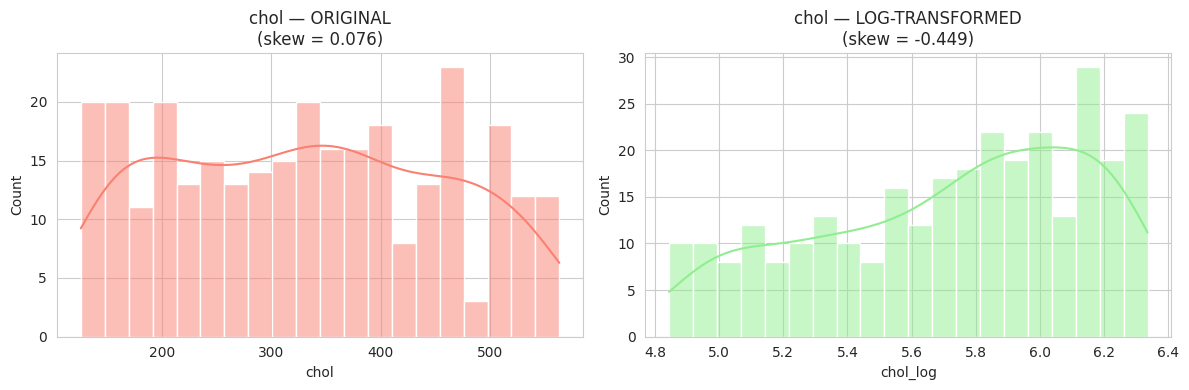

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['chol'], kde=True, color='salmon', ax=ax[0], bins=20)
ax[0].set_title(f"chol — ORIGINAL\n(skew = {df['chol'].skew():.3f})")

sns.histplot(df['chol_log'], kde=True, color='lightgreen', ax=ax[1], bins=20)
ax[1].set_title(f"chol — LOG-TRANSFORMED\n(skew = {df['chol_log'].skew():.3f})")

plt.tight_layout()
plt.show()

### 5.5 Other Transformations (For Reference)

In [18]:
# Demonstrate three more techniques on cholesterol

# Square root — milder than log
df['chol_sqrt'] = np.sqrt(df['chol'])

# Min-Max scaling — rescales values to [0, 1]
df['chol_minmax'] = (df['chol'] - df['chol'].min()) / (df['chol'].max() - df['chol'].min())

# Z-score (Standardization) — centers on 0 with std = 1
df['chol_zscore'] = (df['chol'] - df['chol'].mean()) / df['chol'].std()

# Compare skewness across all transformations
comparison = pd.DataFrame({
    'Original': [df['chol'].skew()],
    'Log':      [df['chol_log'].skew()],
    'Sqrt':     [df['chol_sqrt'].skew()],
    'Min-Max':  [df['chol_minmax'].skew()],
    'Z-score':  [df['chol_zscore'].skew()],
}, index=['Skewness']).round(4)

print("Skewness comparison across transformations:")
comparison

Skewness comparison across transformations:


,Original,Log,Sqrt,Min-Max,Z-score
Skewness,0.0758,-0.449,-0.1818,0.0758,0.0758


## Step 6: Final Cleaned and Transformed DataFrame

In [19]:
print("Final shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nFinal data types:")
print(df.dtypes)
print("\nPreview:")
df.head(10)

Final shape: (300, 18)

Missing values: 0

Final data types:
age            float64
sex              int64
cp               int64
trestbps       float64
chol           float64
fbs              int64
restecg          int64
thalach          int64
exang            int64
oldpeak        float64
slope            int64
ca               int64
thal             int64
target           int64
chol_log       float64
chol_sqrt      float64
chol_minmax    float64
chol_zscore    float64
dtype: object

Preview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_log,chol_sqrt,chol_minmax,chol_zscore
0,36.0,0,0,179.0,385.0,0,0,91,1,4.5,0,3,3,0,5.955837,19.621417,0.592677,0.417429
1,38.0,0,3,167.0,164.0,1,2,201,0,5.7,1,2,3,1,5.105945,12.806248,0.086957,-1.335073
2,74.0,1,1,154.0,179.0,0,0,152,0,5.7,2,0,1,1,5.192957,13.379088,0.121281,-1.216125
3,33.0,1,3,151.0,286.0,0,1,158,1,4.6,1,2,3,0,5.659482,16.911535,0.366133,-0.367629
4,47.0,1,1,124.0,414.0,0,1,181,0,1.2,1,1,3,0,6.028279,20.346990,0.659039,0.647395
5,75.0,0,3,184.0,325.0,1,0,80,1,5.2,2,4,2,0,5.786897,18.027756,0.455378,-0.058364
6,66.0,1,3,105.0,401.0,1,1,82,1,1.3,1,0,1,1,5.996452,20.024984,0.629291,0.544306
7,39.0,1,1,139.0,141.0,1,1,77,1,4.6,2,0,0,1,4.955827,11.874342,0.034325,-1.517460
8,51.0,0,0,124.0,530.0,0,0,184,0,4.3,0,4,1,0,6.274762,23.021729,0.924485,1.567260
9,48.0,1,0,125.0,298.0,0,1,96,0,4.7,1,0,2,1,5.700444,17.262677,0.393593,-0.272470


## Conclusion

We performed three data-wrangling operations on `heart_disease.csv`:

1. **Missing values & inconsistencies**
   - Counted NaNs with `isnull().sum()` and visualized as a heatmap
   - Flagged biologically impossible values (negative ages, cholesterol > 600) as NaN
   - Filled all numeric NaN values with the column **median** (robust to outliers)

2. **Outliers**
   - Visualized with **boxplots** (before and after)
   - Detected numerically using the **IQR rule** (Q1 − 1.5·IQR, Q3 + 1.5·IQR)
   - Treated via **winsorization** — capping outliers at IQR boundaries while preserving all rows

3. **Transformation**
   - Applied `log1p()` to **cholesterol** to reduce its right-skewness
   - Verified skewness decreased toward zero (more normal)
   - Demonstrated sqrt, Min-Max, and Z-score scaling for completeness

The final DataFrame has no missing values, no extreme outliers, and a more symmetric cholesterol distribution — ready for downstream analysis or modeling (e.g., predicting heart disease).

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, reading CSVs, statistics |
| **numpy** | Numerical computing — `np.nan`, `log1p`, `sqrt`, mathematical operations |
| **matplotlib.pyplot** | Base plotting — figure size, titles, axes |
| **seaborn** | Statistical visualization — cleaner boxplots, histograms, heatmaps |

### Functions and Methods Used

#### Data Loading & Inspection
- `pd.read_csv(path)` — read CSV into DataFrame
- `df.shape` — `(rows, columns)`
- `df.head(n)` — first n rows
- `df.info()` — column names, dtypes, non-null counts
- `df.describe()` — summary statistics for numeric columns
- `df.dtypes` — data types
- `df.select_dtypes(include='number')` — selects only numeric columns

#### Missing Value Handling
- `df.isnull()` — boolean mask; True where NaN
- `.sum()` — counts True values
- `df['col'].fillna(value, inplace=True)` — replace NaN with value, modify in place
- `df['col'].median()` — middle value; robust to outliers
- `df.loc[condition, 'col'] = value` — conditional assignment

#### Outlier Detection & Treatment
- `df['col'].quantile(0.25)` — 25th percentile (Q1)
- `df['col'].quantile(0.75)` — 75th percentile (Q3)
- **IQR rule** — outlier if value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR
- `series.clip(lower, upper)` — caps values to [lower, upper] range

#### Transformations
- `np.log1p(x)` — `log(1 + x)`; safe for zero values
- `np.sqrt(x)` — square root transformation
- **Min-Max scaling** — `(x − min) / (max − min)` rescales to [0, 1]
- **Z-score (Standardization)** — `(x − mean) / std` centers on 0 with std = 1
- `df['col'].skew()` — distribution asymmetry

#### Visualization
- `sns.boxplot(y=...)` — box-and-whisker plot
- `sns.histplot(x, kde=True, bins=N)` — histogram with smooth density curve
- `sns.heatmap(matrix, cbar=False, cmap='viridis')` — colored grid showing values
- `plt.subplots(rows, cols, figsize=(w, h))` — grid of plots
- `plt.tight_layout()` — prevents overlap
- `plt.show()` — renders the figure

### Key Concepts

#### Median Imputation
Filling missing values with the column's **median**. Chosen over mean because the mean is dragged by extreme outliers; the median is **robust**.

#### IQR Rule
The **Interquartile Range** is the spread of the middle 50% of data: IQR = Q3 − Q1. Tukey's rule defines a value as an outlier if it lies more than 1.5×IQR below Q1 or above Q3.

#### Winsorization (Capping)
Replacing outliers with the IQR boundary instead of dropping them. Preserves all rows — important for medical datasets where every patient counts.

#### Skewness
A number describing distribution asymmetry:
- **0** → symmetric (bell-shaped)
- **> 0** → right-skewed (long tail on right; mean > median)
- **< 0** → left-skewed (long tail on left; mean < median)
- **|skew| > 1** → strongly skewed

#### Log Transformation
Applying `log()` (or `log1p()`) to a right-skewed variable to compress the long tail. Many ML/statistical methods assume normality, so log makes data more compatible.

#### Why `log1p` not `log`?
`log(0)` is undefined (−∞). `log1p(x) = log(1 + x)` returns 0 for input 0 — safe for any non-negative data including zeros.

#### Min-Max Scaling
Rescales to [0, 1] via `(x − min)/(max − min)`. Preserves shape; only changes range.

#### Z-score Standardization
Transforms to mean = 0, std = 1, via `(x − mean)/std`. Common preprocessing for ML models sensitive to scale.

## Viva Questions (with Answers)

**Q1. What is data wrangling?**
The process of cleaning and preparing raw data for analysis — handling missing values, inconsistencies, outliers, and applying transformations. Typically takes 60–80% of any data science project.

**Q2. Why is data wrangling especially important for medical data?**
Inconsistencies and outliers can lead to wrong diagnoses or wrong predictions in models. Medical decisions are high-stakes, so data quality is paramount.

**Q3. What does each column in the heart-disease dataset represent?**
- `age`, `sex`, `cp` (chest pain type), `trestbps` (resting BP), `chol` (cholesterol), `fbs` (fasting blood sugar), `restecg`, `thalach` (max heart rate), `exang` (exercise angina), `oldpeak` (ST depression), `slope`, `ca` (vessels), `thal` (thalassemia), `target` (1 = disease, 0 = healthy).

**Q4. Why use median instead of mean for imputation?**
Median is **robust to outliers**; mean is dragged by extreme values. Critical when data has outliers.

**Q5. What is the IQR method for outlier detection?**
Compute Q1 (25th percentile) and Q3 (75th percentile). IQR = Q3 − Q1. A value is an outlier if it's below Q1 − 1.5·IQR or above Q3 + 1.5·IQR.

**Q6. What is winsorization?**
Capping outliers at the IQR boundary instead of removing rows. Preserves all data points.

**Q7. Why cap rather than drop outliers?**
- Preserves all rows (better for small datasets like medical records)
- Outliers might be real values, not data errors
- Dropping loses information

**Q8. What is skewness?**
A number describing distribution asymmetry. Zero = symmetric. Positive = right-skewed (tail on right). Negative = left-skewed.

**Q9. Why log-transform cholesterol?**
Cholesterol is typically right-skewed; log makes the distribution more normal, which many statistical methods require.

**Q10. Why use `np.log1p()` instead of `np.log()`?**
`log(0)` is undefined. `log1p(x) = log(1+x)` handles zero safely — `log1p(0) = log(1) = 0`.

**Q11. Difference between Min-Max scaling and Standardization?**
- **Min-Max**: rescales to [0, 1] via `(x − min)/(max − min)` — preserves shape
- **Z-score**: centers on 0 with std = 1 via `(x − mean)/std` — better for normal data

**Q12. What does the box in a boxplot show?**
The middle 50% of the data — from Q1 (bottom) to Q3 (top). The line inside is the median.

**Q13. What are whiskers in a boxplot?**
Lines extending from the box to the smallest and largest values within 1.5×IQR. Anything beyond is shown as outlier dots.

**Q14. What does `.clip(lower, upper)` do?**
Replaces any values below `lower` with `lower`, and any values above `upper` with `upper`. The middle range is unchanged.

**Q15. Difference between dropping and capping outliers?**
- **Dropping** removes the entire row
- **Capping** replaces the value with the IQR boundary, keeping the row

**Q16. What does `df.select_dtypes(include='number')` do?**
Selects only numeric columns from the DataFrame, useful for applying transformations only to numeric data.

**Q17. Other transformations besides log?**
- Square root (mild skew)
- Reciprocal (1/x) (strong skew correction)
- Box-Cox (auto-selects best power)
- Yeo-Johnson (handles negatives)
- Min-Max scaling
- Standardization (Z-score)

**Q18. What's the purpose of `inplace=True` in `fillna`?**
Modifies the DataFrame directly without returning a new copy. Saves memory.

**Q19. Why don't we cap binary or categorical columns?**
Binary columns (0/1) and ordinal categories don't have meaningful "outliers" — capping them would corrupt the data. We cap only continuous numeric variables.

**Q20. How would you handle missing values for categorical columns?**
Use the **mode** (most frequent value) instead of median. For example: `df['col'].fillna(df['col'].mode()[0])`.